## Ola Bike Ride Request Forecast using (LinearRegression, Lasso, Ridge, RandomForestRegressor) in Scikit-Learn

### 1. Importing Libraries

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

### 2. Loading Dataset

In [2]:
url = "https://media.githubusercontent.com/media/fatahrahimi330/100-Machine-Learning-Projects/refs/heads/master/58-Ola%20Bike%20Ride%20Request%20Forecast/ola.csv"

In [12]:
df = pd.read_csv(url)
df.head()

,datetime,season,weather,temp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,3,2,7.653428,122.430885,18.783703,5,128,315.731778
1,2011-01-01 01:00:00,4,3,13.269244,101.703802,14.035245,36,184,340.457093
2,2011-01-01 02:00:00,1,3,30.886922,77.583743,45.365080,34,97,224.278595
3,2011-01-01 03:00:00,3,1,10.463377,114.925671,25.347168,6,47,132.169549
4,2011-01-01 04:00:00,3,4,30.214783,149.193592,20.288982,14,199,315.867137


### 3. Data Preprocessing

In [4]:
df.shape

(10886, 9)

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
season,10886.0,2.493937,1.120531,1.000000,1.000000,2.000000,3.000000,4.000000
weather,10886.0,2.491916,1.123139,1.000000,1.000000,2.000000,4.000000,4.000000
temp,9254.0,23.240116,20.311144,-22.743852,12.470555,20.743790,29.394576,211.102548
humidity,9254.0,124.452421,75.568291,32.713561,87.846187,112.180064,137.301002,672.687236
windspeed,9254.0,34.549616,28.417263,-1.407737,17.963252,30.945593,44.029018,244.921965
casual,10886.0,24.517545,14.390014,0.000000,12.000000,25.000000,37.000000,49.000000
registered,10886.0,99.551442,57.541131,0.000000,50.000000,100.000000,149.000000,199.000000
count,10886.0,224.177267,75.228602,-12.769738,170.140221,224.257587,278.407366,464.839068


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  object 
 1   season      10886 non-null  int64  
 2   weather     10886 non-null  int64  
 3   temp        9254 non-null   float64
 4   humidity    9254 non-null   float64
 5   windspeed   9254 non-null   float64
 6   casual      10886 non-null  int64  
 7   registered  10886 non-null  int64  
 8   count       10886 non-null  float64
dtypes: float64(4), int64(4), object(1)
memory usage: 765.6+ KB


In [7]:
df.isnull().sum()

,0
datetime,0
season,0
weather,0
temp,1632
humidity,1632
windspeed,1632
casual,0
registered,0
count,0


In [13]:
parts = df["datetime"].str.split(" ", n=2, expand=True)
df["date"] = parts[0]
df["time"] = parts[1].str[:2].astype('int')
df.head()

,datetime,season,weather,temp,humidity,windspeed,casual,registered,count,date,time
0,2011-01-01 00:00:00,3,2,7.653428,122.430885,18.783703,5,128,315.731778,2011-01-01,0
1,2011-01-01 01:00:00,4,3,13.269244,101.703802,14.035245,36,184,340.457093,2011-01-01,1
2,2011-01-01 02:00:00,1,3,30.886922,77.583743,45.365080,34,97,224.278595,2011-01-01,2
3,2011-01-01 03:00:00,3,1,10.463377,114.925671,25.347168,6,47,132.169549,2011-01-01,3
4,2011-01-01 04:00:00,3,4,30.214783,149.193592,20.288982,14,199,315.867137,2011-01-01,4


In [14]:
parts = df["date"].str.split("-", n=3, expand=True)
parts

,0,1,2
0,2011,01,01
1,2011,01,01
2,2011,01,01
3,2011,01,01
4,2011,01,01
...,...,...,...
10881,2012,03,29
10882,2012,03,29
10883,2012,03,29
10884,2012,03,29


In [16]:
df["day"] = parts[2].astype('int')
df["month"] = parts[1].astype('int')
df["year"] = parts[0].astype('int')
df.head()

,datetime,season,weather,temp,humidity,windspeed,casual,registered,count,date,time,year,month,day
0,2011-01-01 00:00:00,3,2,7.653428,122.430885,18.783703,5,128,315.731778,2011-01-01,0,2011,1,1
1,2011-01-01 01:00:00,4,3,13.269244,101.703802,14.035245,36,184,340.457093,2011-01-01,1,2011,1,1
2,2011-01-01 02:00:00,1,3,30.886922,77.583743,45.365080,34,97,224.278595,2011-01-01,2,2011,1,1
3,2011-01-01 03:00:00,3,1,10.463377,114.925671,25.347168,6,47,132.169549,2011-01-01,3,2011,1,1
4,2011-01-01 04:00:00,3,4,30.214783,149.193592,20.288982,14,199,315.867137,2011-01-01,4,2011,1,1


In [17]:
from datetime import datetime

df['datetime'] = pd.to_datetime(df['datetime'])

df['year'] = df['datetime'].dt.year
df['month'] = df['datetime'].dt.month
df['day'] = df['datetime'].dt.day

def weekend_or_weekday(year, month, day):
    try:
        d = datetime(year, month, day)
        return 0 if d.weekday() > 4 else 1
    except ValueError:
        return np.nan 

df['weekday'] = df.apply(lambda x: weekend_or_weekday(x['year'], x['month'], x['day']), axis=1)

df.head()

,datetime,season,weather,temp,humidity,windspeed,casual,registered,count,date,time,year,month,day,weekday
0,2011-01-01 00:00:00,3,2,7.653428,122.430885,18.783703,5,128,315.731778,2011-01-01,0,2011,1,1,0
1,2011-01-01 01:00:00,4,3,13.269244,101.703802,14.035245,36,184,340.457093,2011-01-01,1,2011,1,1,0
2,2011-01-01 02:00:00,1,3,30.886922,77.583743,45.365080,34,97,224.278595,2011-01-01,2,2011,1,1,0
3,2011-01-01 03:00:00,3,1,10.463377,114.925671,25.347168,6,47,132.169549,2011-01-01,3,2011,1,1,0
4,2011-01-01 04:00:00,3,4,30.214783,149.193592,20.288982,14,199,315.867137,2011-01-01,4,2011,1,1,0


In [18]:
def am_or_pm(x):
    if x > 11:
        return 1
    else:
        return 0


df['am_or_pm'] = df['time'].apply(am_or_pm)
df.head()

,datetime,season,weather,temp,humidity,windspeed,casual,registered,count,date,time,year,month,day,weekday,am_or_pm
0,2011-01-01 00:00:00,3,2,7.653428,122.430885,18.783703,5,128,315.731778,2011-01-01,0,2011,1,1,0,0
1,2011-01-01 01:00:00,4,3,13.269244,101.703802,14.035245,36,184,340.457093,2011-01-01,1,2011,1,1,0,0
2,2011-01-01 02:00:00,1,3,30.886922,77.583743,45.365080,34,97,224.278595,2011-01-01,2,2011,1,1,0,0
3,2011-01-01 03:00:00,3,1,10.463377,114.925671,25.347168,6,47,132.169549,2011-01-01,3,2011,1,1,0,0
4,2011-01-01 04:00:00,3,4,30.214783,149.193592,20.288982,14,199,315.867137,2011-01-01,4,2011,1,1,0,0


In [19]:
from datetime import date
import holidays


def is_holiday(x):

    india_holidays = holidays.country_holidays('IN')

    if india_holidays.get(x):
        return 1
    else:
        return 0


df['holidays'] = df['date'].apply(is_holiday)
df.head()

,datetime,season,weather,temp,humidity,windspeed,casual,registered,count,date,time,year,month,day,weekday,am_or_pm,holidays
0,2011-01-01 00:00:00,3,2,7.653428,122.430885,18.783703,5,128,315.731778,2011-01-01,0,2011,1,1,0,0,0
1,2011-01-01 01:00:00,4,3,13.269244,101.703802,14.035245,36,184,340.457093,2011-01-01,1,2011,1,1,0,0,0
2,2011-01-01 02:00:00,1,3,30.886922,77.583743,45.365080,34,97,224.278595,2011-01-01,2,2011,1,1,0,0,0
3,2011-01-01 03:00:00,3,1,10.463377,114.925671,25.347168,6,47,132.169549,2011-01-01,3,2011,1,1,0,0,0
4,2011-01-01 04:00:00,3,4,30.214783,149.193592,20.288982,14,199,315.867137,2011-01-01,4,2011,1,1,0,0,0


In [20]:
df.drop(['datetime', 'date'],
        axis=1,
        inplace=True)

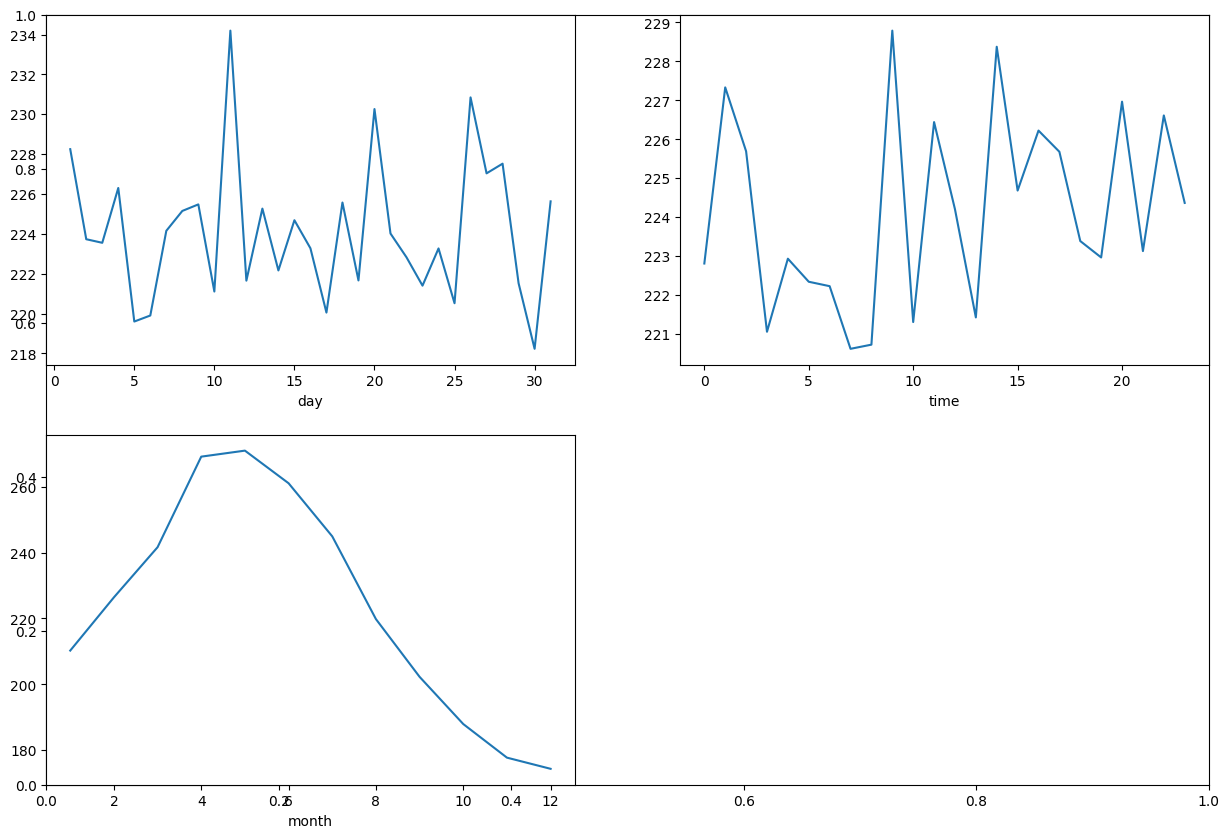

In [21]:
features = ['day', 'time', 'month']

plt.subplots(figsize=(15, 10))
for i, col in enumerate(features):
    plt.subplot(2, 2, i + 1)
    df.groupby(col).mean()['count'].plot()
plt.show()

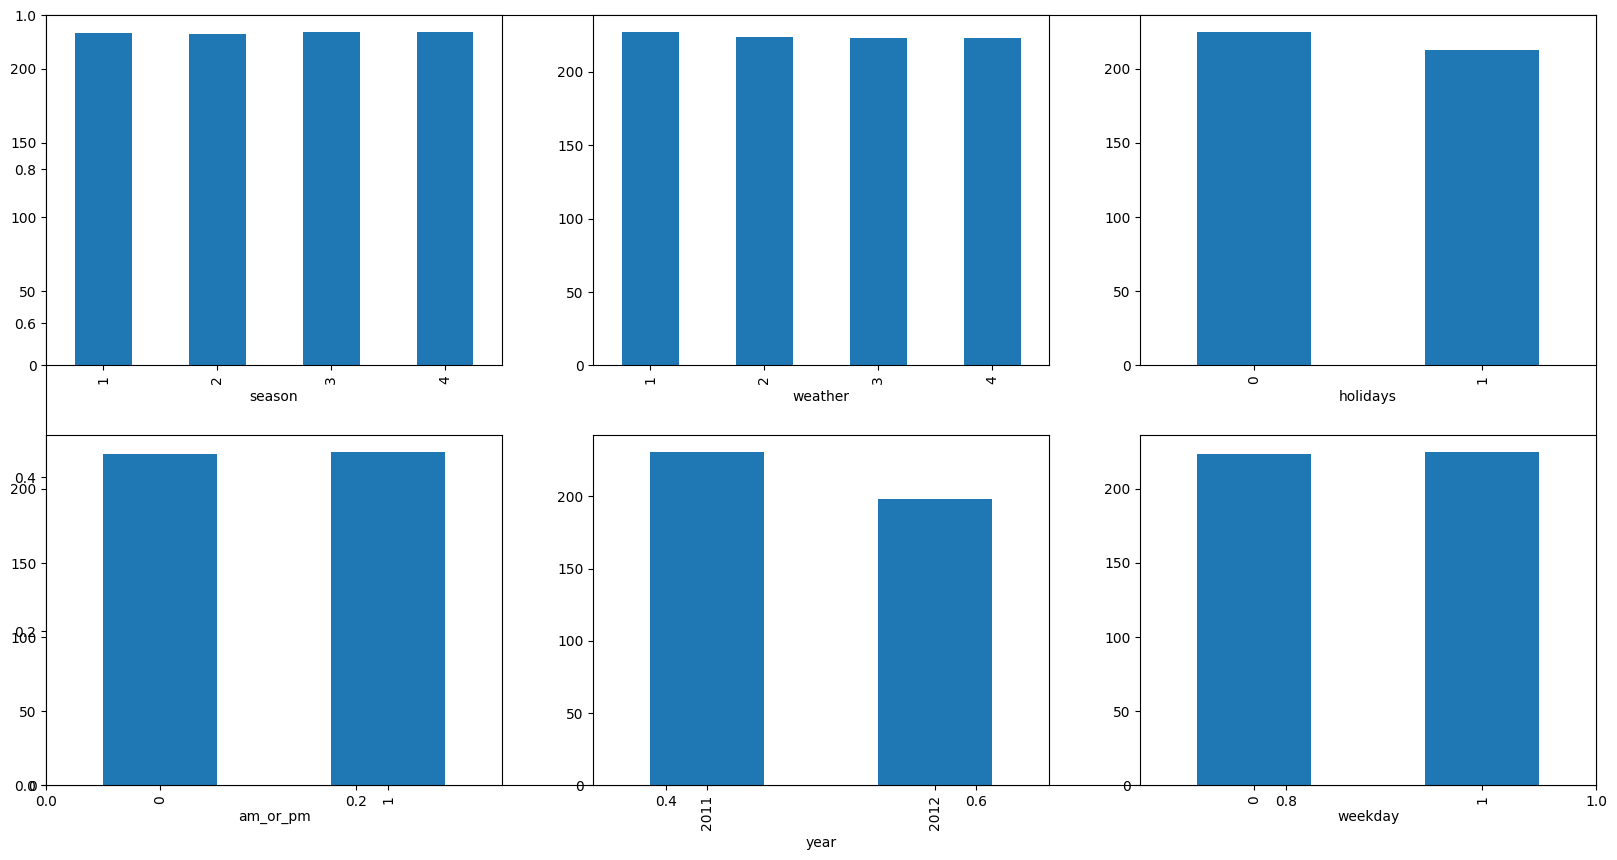

In [22]:
features = ['season', 'weather', 'holidays', 'am_or_pm', 'year', 'weekday']

plt.subplots(figsize=(20, 10))
for i, col in enumerate(features):
    plt.subplot(2, 3, i + 1)
    df.groupby(col).mean()['count'].plot.bar()
plt.show()

/tmp/ipykernel_14409/2427621823.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[col])
/tmp/ipykernel_14409/2427621823.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[col])


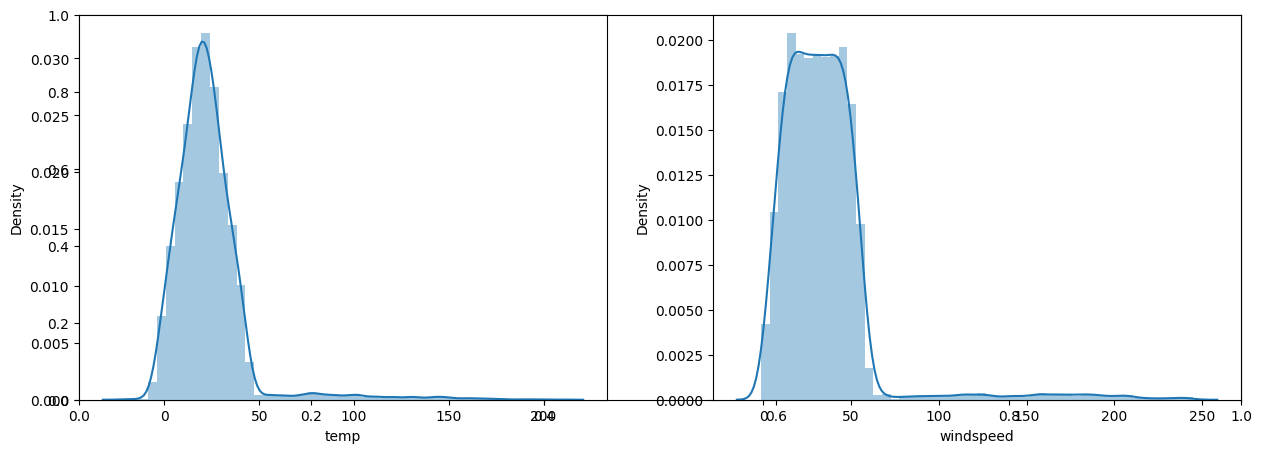

In [24]:
features = ['temp', 'windspeed']

plt.subplots(figsize=(15, 5))
for i, col in enumerate(features):
  plt.subplot(1, 2, i + 1)
  sns.distplot(df[col])
plt.show()

In [25]:
num_rows = df.shape[0] - df[df['windspeed']<32].shape[0]
print(f'Number of rows that will be lost if we remove outliers is equal to {num_rows}.')

Number of rows that will be lost if we remove outliers is equal to 6091.


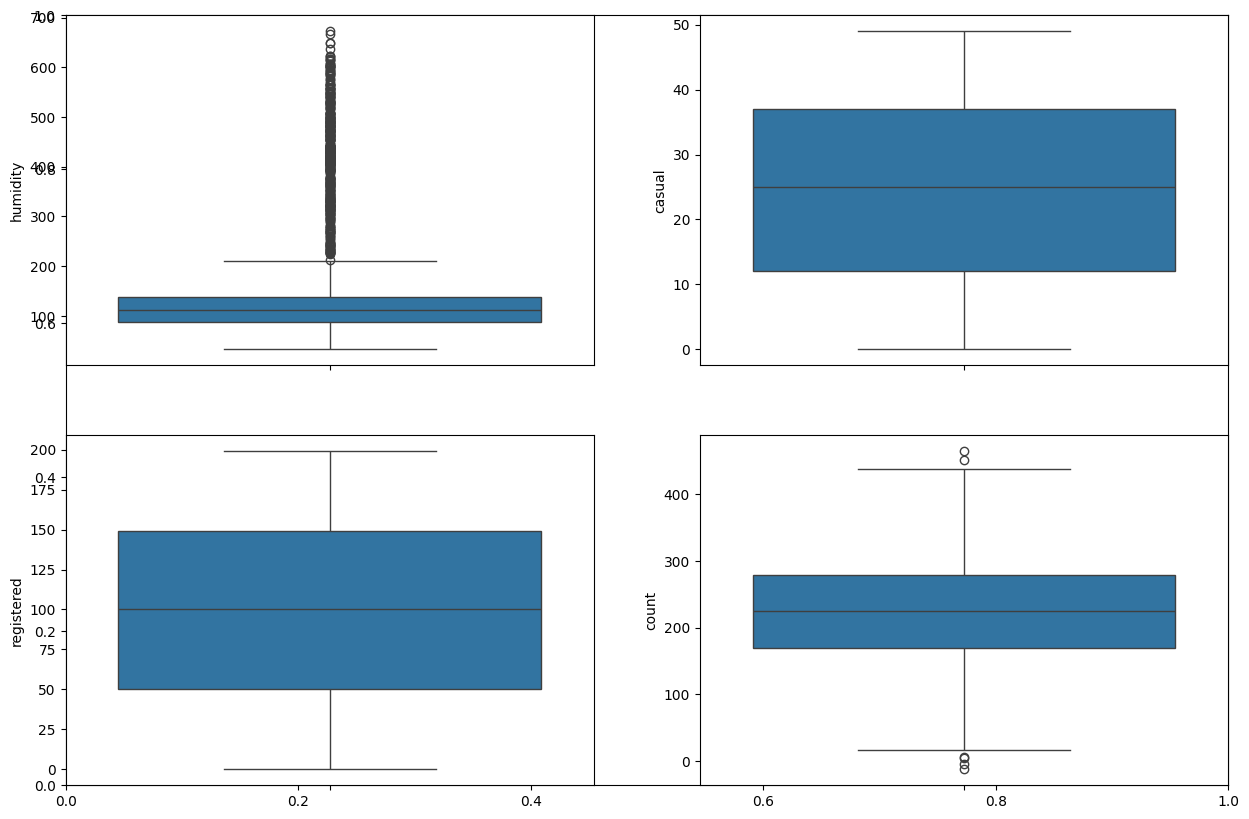

In [26]:
features = ['humidity', 'casual', 'registered', 'count']

plt.subplots(figsize=(15, 10))
for i, col in enumerate(features):
    plt.subplot(2, 2, i + 1)
    sns.boxplot(df[col])
plt.show()

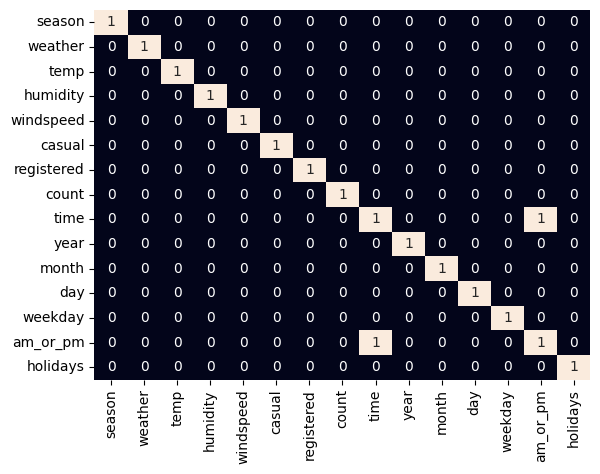

In [28]:
sns.heatmap(df.corr() > 0.8,
           annot=True,
           cbar=False)
plt.show()

In [29]:
df.drop(['registered', 'time'], axis=1, inplace=True)
df = df[(df['windspeed'] < 32) & (df['humidity'] > 0)]

In [31]:
X = df.drop(['count'], axis=1).values
y = df['count'].values

In [32]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.1, random_state=22)
X_train.shape, X_test.shape

((4315, 12), (480, 12))

In [34]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### 4. Build and Fit the Models

In [37]:
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error as mae
models = [LinearRegression(), Lasso(), RandomForestRegressor(), Ridge()]

for i in range(len(models)):
    models[i].fit(X_train, y_train)

    print(f'{models[i]} :')

    train_preds = models[i].predict(X_train)
    print('Training Error : ', mae(y_train, train_preds))

    val_preds = models[i].predict(X_test)
    print('Validation Error : ', mae(y_test, val_preds))
    print()

LinearRegression() :
Training Error :  55.51892217832468
Validation Error :  55.7458418966403

Lasso() :
Training Error :  55.53694296308145
Validation Error :  55.87070729053223

RandomForestRegressor() :
Training Error :  20.58206885910641
Validation Error :  54.990281406060646

Ridge() :
Training Error :  55.518884098595414
Validation Error :  55.74662268167663



In [40]:
best_model = None
best_score = float('inf')

for model in models:
    model.fit(X_train, y_train)
    
    preds = model.predict(X_test)
    score = mae(y_test, preds)
    
    if score < best_score:
        best_score = score
        best_model = model

print("Best model:", best_model)

Best model: RandomForestRegressor()


### 5. Make Prediction

In [41]:
import pandas as pd
import numpy as np

def prepare_input(datetime_string):
    dt = pd.to_datetime(datetime_string)
    return pd.DataFrame([{
        'weekday': dt.weekday(),
        'hour': dt.hour,
        'month': dt.month,
        'year': dt.year,
        'dayofyear': dt.dayofyear,
        'weekofyear': int(dt.isocalendar().week),
        'hour_sin': np.sin(2 * np.pi * dt.hour / 24),
        'hour_cos': np.cos(2 * np.pi * dt.hour / 24),
        'weekday_sin': np.sin(2 * np.pi * dt.weekday() / 7),
        'weekday_cos': np.cos(2 * np.pi * dt.weekday() / 7),
        'month_sin': np.sin(2 * np.pi * dt.month / 12),
        'month_cos': np.cos(2 * np.pi * dt.month / 12)
    }])

In [42]:
new_data = prepare_input('2026-03-27 14:30:00')

prediction = best_model.predict(new_data)

print("Prediction:", prediction[0])

Prediction: 280.06104448040486


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(


### 6. Evaluate the Models

In [44]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred = best_model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("📊 Model Evaluation Metrics:")
print("MAE  :", mae)
print("MSE  :", mse)
print("RMSE :", rmse)
print("R²   :", r2)

📊 Model Evaluation Metrics:
MAE  : 55.284354458571855
MSE  : 4501.362388083608
RMSE : 67.0921931977455
R²   : 0.20617101621016143


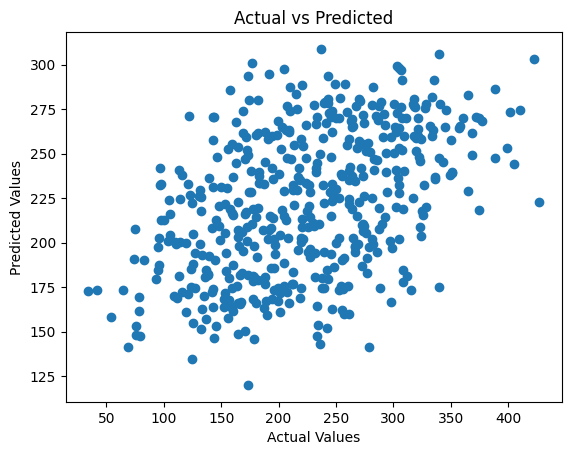

In [45]:
plt.figure()
plt.scatter(y_test, y_pred)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted")

plt.show()

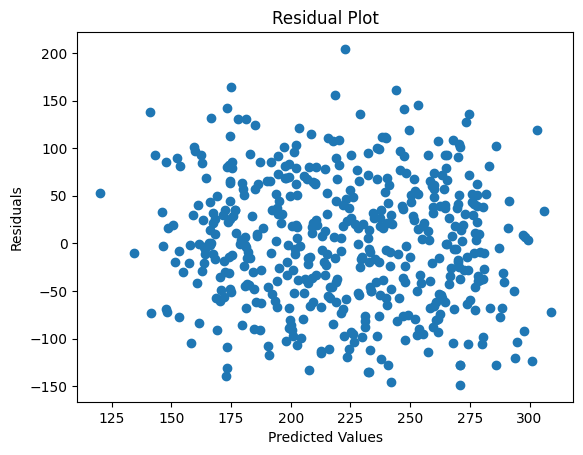

In [46]:
residuals = y_test - y_pred

plt.figure()
plt.scatter(y_pred, residuals)

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()

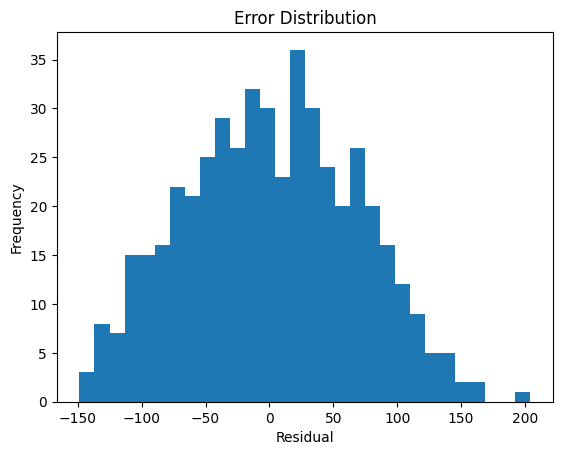

In [47]:
plt.figure()
plt.hist(residuals, bins=30)

plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Error Distribution")

plt.show()

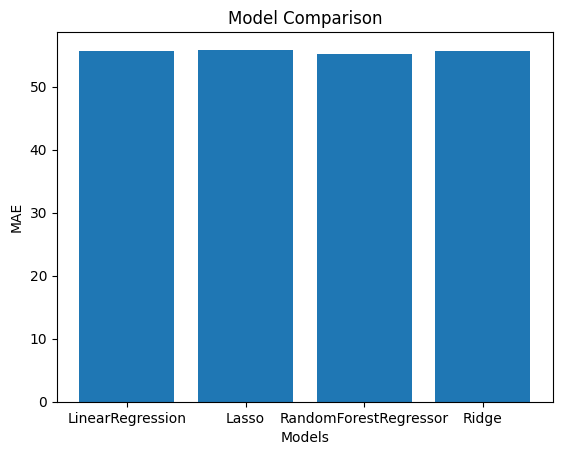

In [48]:
results = {}

for model in models:
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    
    results[type(model).__name__] = mean_absolute_error(y_test, preds)

# Plot comparison
plt.figure()
plt.bar(results.keys(), results.values())

plt.xlabel("Models")
plt.ylabel("MAE")
plt.title("Model Comparison")

plt.show()